In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd


# --- Cargar CSV ---
df_train = pd.read_csv('/content/drive/My Drive/Datos_train_sAct.csv')
df_test  = pd.read_csv('/content/drive/My Drive/Datos_test_sAct.csv')
# --- Eliminar columna "Motivo de baja" ---
df_train = df_train.drop('Fecha de evaluación_num', axis=1)
df_test = df_test.drop('Fecha de evaluación_num', axis=1)

df_train = df_train.drop('Inscripción / Reinscripción', axis=1)
df_test = df_test.drop('Inscripción / Reinscripción', axis=1)

# --- Eliminar columnas específicas de ambos DataFrames ---
cols_to_drop = ['Fecha de nacimiento en dias', 'Edad_en_fecha_de_registro_dias']

df_train = df_train.drop(columns=cols_to_drop, errors='ignore')
df_test  = df_test.drop(columns=cols_to_drop, errors='ignore')

print("✅ Columnas eliminadas correctamente.")
print("Columnas actuales en df_train:\n", df_train.columns)
print("*******************+")
print(df_test.dtypes)


✅ Columnas eliminadas correctamente.
Columnas actuales en df_train:
 Index(['Matrícula', 'Número de hermanos en la familia',
       'Ingresos por apoyo gubernamental', 'Total de ingresos mensuales',
       'Total de egresos', 'Ingreso Per Cápita', 'Porcentaje de Beca',
       'Edad en años', 'Sexo', 'Programa', 'Grupo', 'Transporte del INA',
       'Clínica de Adscripción en el IMSS',
       'Inst. en la que reciben servicio médico', 'Ciudad', 'Estado',
       'Hospital donde nació', 'Medio x el cual se enteró de Institución',
       'Ocupación del padre', 'Ocupación de la madre', 'Escolaridad del padre',
       'Escolaridad de la madre', 'Integrantes Familia (Incluye al alumno)',
       'Nivel Socioeconómico', 'Medio de Traslado (Transportación)',
       'Diagnóstico Etiológico', 'Diagnostico Fisiologico',
       'Diagnostico Funcional', 'Diagnostico Topografico', 'Nivel GMFCS',
       'Categoria_Lugar', 'Internet_si', 'Teléfono_si', 'Luz_si',
       'Baja General'],
      dtype='obje

=== Distribución de 'Edad en años' en TRAIN ===
Edad en años
2.0      1
3.0      9
4.0      9
5.0     21
6.0     24
7.0     17
8.0     30
9.0     23
10.0    30
11.0    34
12.0    35
13.0    35
14.0    48
15.0    47
16.0    63
17.0    60
18.0    44
19.0    67
20.0    43
21.0    36
22.0    34
23.0    36
24.0    37
25.0    36
26.0    21
27.0    16
28.0    13
29.0    14
30.0     7
31.0     5
32.0     8
33.0     5
34.0     8
35.0     3
38.0     2
39.0     2
40.0     1
41.0     1
42.0     3
43.0     2
44.0     3
45.0     2
46.0     2
51.0     1
84.0     1
Name: count, dtype: int64

Total de valores únicos en TRAIN: 45

=== Distribución de 'Edad en años' en TEST ===
Edad en años
3.0      4
5.0      4
6.0      3
7.0      9
8.0     12
9.0      3
10.0    11
11.0    11
12.0     7
13.0     6
14.0    13
15.0    18
16.0    10
17.0    20
18.0    11
19.0    15
20.0    13
21.0    17
22.0    12
23.0     3
24.0     5
25.0     4
26.0     5
27.0     4
28.0     1
29.0     2
30.0     2
31.0     1
33.0     2


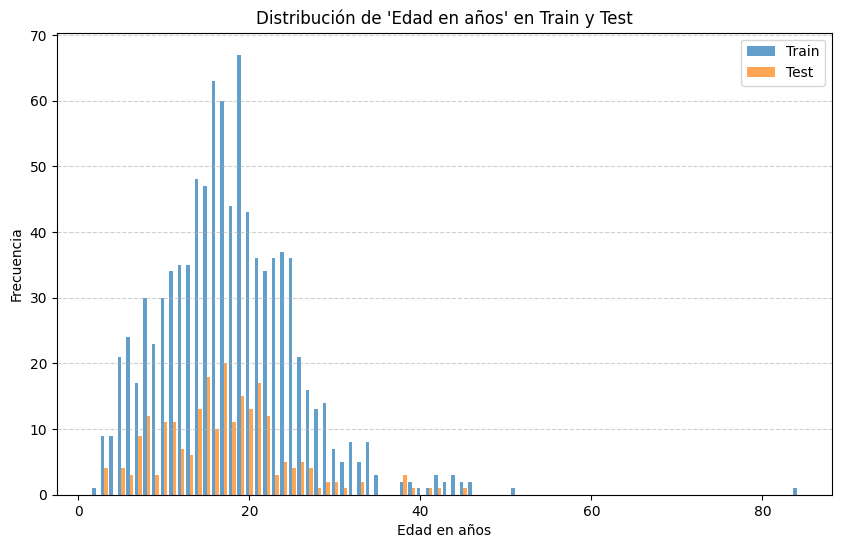

In [ ]:
print("=== Distribución de 'Edad en años' en TRAIN ===")
print(df_train['Edad en años'].value_counts().sort_index())
print("\nTotal de valores únicos en TRAIN:", df_train['Edad en años'].nunique())

print("\n=== Distribución de 'Edad en años' en TEST ===")
print(df_test['Edad en años'].value_counts().sort_index())
print("\nTotal de valores únicos en TEST:", df_test['Edad en años'].nunique())

import matplotlib.pyplot as plt

# --- Contar frecuencias ---
train_counts = df_train['Edad en años'].value_counts().sort_index()
test_counts = df_test['Edad en años'].value_counts().sort_index()

# --- Crear figura ---
plt.figure(figsize=(10, 6))

# --- Graficar ---
plt.bar(train_counts.index - 0.2, train_counts.values, width=0.4, label='Train', alpha=0.7)
plt.bar(test_counts.index + 0.2, test_counts.values, width=0.4, label='Test', alpha=0.7)

# --- Estilo ---
plt.title("Distribución de 'Edad en años' en Train y Test")
plt.xlabel("Edad en años")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [ ]:
# Importaciones necesarias
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd

# --- Separar variables y etiquetas ---
X_train = df_train.drop(['Baja General'], axis=1)
y_train = df_train['Baja General'].astype(int)

X_test = df_test.drop(['Baja General'], axis=1)
y_test = df_test['Baja General'].astype(int)

In [ ]:
!pip install catboost


In [ ]:
!pip install optuna

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from catboost import CatBoostClassifier


In [ ]:
# Importaciones necesarias para que la función sea autónoma
from tensorflow.keras.models import Sequential
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def check_overfitting(model, X_train, y_train, X_test, y_test, model_name="Modelo"):
    """
    Evalúa, imprime y grafica el rendimiento de un modelo en los conjuntos de
    entrenamiento y prueba para detectar overfitting.
    """
    print(f"\n=== Verificación de Overfitting: {model_name} ===")

    # Lógica de predicción adaptada al tipo de modelo
    if isinstance(model, Sequential):  # Modelo de Keras
        y_train_proba = model.predict(X_train).flatten()
        y_train_pred = (y_train_proba > 0.5).astype(int)
        y_test_proba = model.predict(X_test).flatten()
        y_test_pred = (y_test_proba > 0.5).astype(int)
    else:  # Modelos de Scikit-learn, XGBoost, CatBoost, etc.
        y_train_pred = model.predict(X_train)
        y_train_proba = model.predict_proba(X_train)[:, 1]
        y_test_pred = model.predict(X_test)
        y_test_proba = model.predict_proba(X_test)[:, 1]

    # Cálculo de métricas
    metrics = {
        'model': model_name,
        'acc_train': accuracy_score(y_train, y_train_pred),
        'f1_train': f1_score(y_train, y_train_pred),
        'auc_train': roc_auc_score(y_train, y_train_proba),
        'acc_test': accuracy_score(y_test, y_test_pred),
        'f1_test': f1_score(y_test, y_test_pred),
        'auc_test': roc_auc_score(y_test, y_test_proba)
    }
    metrics['gap_acc'] = metrics['acc_train'] - metrics['acc_test']
    metrics['gap_f1'] = metrics['f1_train'] - metrics['f1_test']
    metrics['gap_auc'] = metrics['auc_train'] - metrics['auc_test']

    # Imprimir resultados numéricos
    print(f"Train -> Accuracy: {metrics['acc_train']:.4f}, F1: {metrics['f1_train']:.4f}, AUC: {metrics['auc_train']:.4f}")
    print(f"Test  -> Accuracy: {metrics['acc_test']:.4f}, F1: {metrics['f1_test']:.4f}, AUC: {metrics['auc_test']:.4f}")

    # Gráfico comparativo
    labels = ["Accuracy", "F1-score", "ROC-AUC"]
    train_scores = [metrics['acc_train'], metrics['f1_train'], metrics['auc_train']]
    test_scores = [metrics['acc_test'], metrics['f1_test'], metrics['auc_test']]

    x = np.arange(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    rects1 = ax.bar(x - width/2, train_scores, width, label='Train')
    rects2 = ax.bar(x + width/2, test_scores, width, label='Test')

    ax.set_ylabel('Scores')
    ax.set_title(f'Comparativa Train vs. Test - {model_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.bar_label(rects1, padding=3, fmt='%.3f')
    ax.bar_label(rects2, padding=3, fmt='%.3f')
    fig.tight_layout()
    plt.show()

    return metrics


ENTRENANDO CATBOOST SEGURO Y OPTIMIZADO
=== VERIFICACIONES PREVIAS ===
Shape df_train: (939, 37)
Shape df_test: (235, 37)
Columnas categóricas identificadas: ['Sexo', 'Programa', 'Grupo', 'Transporte del INA', 'Clínica de Adscripción en el IMSS', 'Inst. en la que reciben servicio médico', 'Ciudad', 'Estado', 'Hospital donde nació', 'Medio x el cual se enteró de Institución', 'Ocupación del padre', 'Ocupación de la madre', 'Escolaridad del padre', 'Escolaridad de la madre', 'Integrantes Familia (Incluye al alumno)', 'Nivel Socioeconómico', 'Medio de Traslado (Transportación)', 'Diagnóstico Etiológico', 'Diagnostico Fisiologico', 'Diagnostico Funcional', 'Diagnostico Topografico', 'Nivel GMFCS', 'Categoria_Lugar']


/tmp/ipython-input-235900602.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_train_cat = X_train_cat.applymap(lambda v: int(v) if isinstance(v, bool) else v)
/tmp/ipython-input-235900602.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_test_cat  = X_test_cat.applymap(lambda v: int(v) if isinstance(v, bool) else v)


0:	test: 0.7407500	best: 0.7407500 (0)	total: 121ms	remaining: 3m 2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8120833333
bestIteration = 29

Shrink model to first 30 iterations.

EVALUANDO CATBOOST MEJORADO

=== Verificación de Overfitting: CatBoost Mejorado ===
Train -> Accuracy: 0.7646, F1: 0.8196, AUC: 0.8462
Test  -> Accuracy: 0.7404, F1: 0.8013, AUC: 0.8121


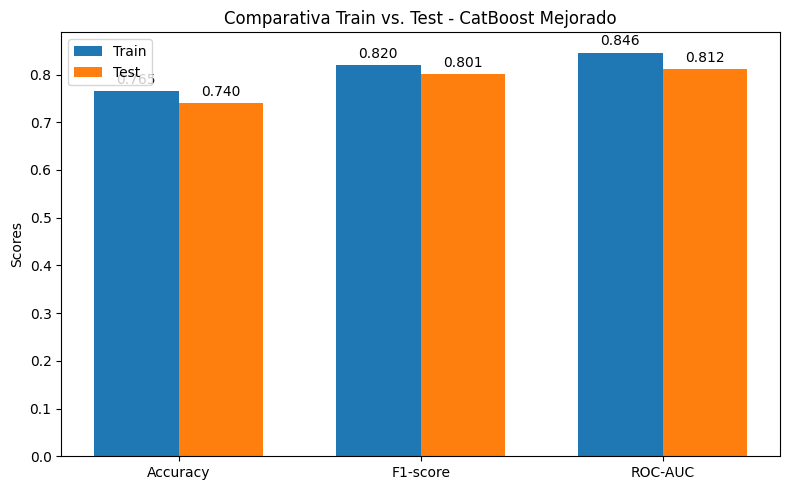

In [ ]:

print("\n" + "="*50 + "\nENTRENANDO CATBOOST SEGURO Y OPTIMIZADO\n" + "="*50)

# ------------------------------
# 1️⃣ VERIFICACIONES PREVIAS (CRÍTICO)
# ------------------------------
print("=== VERIFICACIONES PREVIAS ===")
print(f"Shape df_train: {df_train.shape}")
print(f"Shape df_test: {df_test.shape}")

# Verificar que la columna objetivo existe
assert 'Baja General' in df_train.columns, "❌ 'Baja General' no está en df_train"
assert 'Baja General' in df_test.columns, "❌ 'Baja General' no está en df_test"

# ------------------------------
# 2️⃣ PREPARAR DATOS (TU CÓDIGO ORIGINAL MEJORADO)
# ------------------------------
X_train_cat = df_train.drop(['Baja General'], axis=1).copy()
X_test_cat  = df_test.drop(['Baja General'], axis=1).copy()

# Convertir booleanos a int explícitamente
X_train_cat = X_train_cat.applymap(lambda v: int(v) if isinstance(v, bool) else v)
X_test_cat  = X_test_cat.applymap(lambda v: int(v) if isinstance(v, bool) else v)

# Identificar columnas categóricas
categorical_features = X_train_cat.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Columnas categóricas identificadas: {categorical_features}")

# Convertir a category (solo si hay columnas categóricas)
if categorical_features:
    for col in categorical_features:
        X_train_cat[col] = X_train_cat[col].astype('category')
        # Para test, usar las categorías de train para consistencia
        X_test_cat[col] = X_test_cat[col].astype('category')
else:
    print("⚠️ No se encontraron columnas categóricas")

# Usar las y originales para consistencia
y_train_cat = df_train['Baja General'].astype(int)
y_test_cat = df_test['Baja General'].astype(int)

# ------------------------------
# 3️⃣ MODELO MEJORADO CON MÁS REGULARIZACIÓN
# ------------------------------
model_cat_tuned = CatBoostClassifier(
    iterations=1500,                  # Aumentamos un poco por si el learning_rate es más bajo
    learning_rate=0.03,               # Tasa de aprendizaje más pequeña para un aprendizaje más fino
    depth=5,                          # Reducimos la profundidad para limitar la complejidad
    l2_leaf_reg=3,                    # 🔥 Parámetro clave: Añadimos regularización L2
    subsample=0.8,                    # 🔥 Usar solo el 80% de los datos para cada árbol
    auto_class_weights='Balanced',    # 🔥 Para manejar clases desbalanceadas
    cat_features=categorical_features,
    early_stopping_rounds=50,         # Mantenemos el early stopping, es fundamental
    verbose=100,
    random_state=42,
    eval_metric='AUC'
)

# ------------------------------
# 4️⃣ ENTRENAMIENTO (sin cambios)
# ------------------------------
model_cat_tuned.fit(
    X_train_cat, y_train_cat,
    eval_set=(X_test_cat, y_test_cat),
    use_best_model=True,
    verbose=100
)

# ------------------------------
# 5️⃣ EVALUACIÓN Y VERIFICACIÓN DE OVERFITTING
# ------------------------------
print("\n" + "="*50 + "\nEVALUANDO CATBOOST MEJORADO\n" + "="*50)
results_cat_tuned = check_overfitting(
    model_cat_tuned,
    X_train_cat, y_train_cat,
    X_test_cat, y_test_cat,
    model_name="CatBoost Mejorado"
)

## SEGUNDO


CARGANDO Y PREPARANDO DATOS

INICIANDO BÚSQUEDA RÁPIDA
Fitting 2 folds for each of 15 candidates, totalling 30 fits

--- Búsqueda Finalizada ---
Mejor puntaje (AUC en CV): 0.8003801945313332
Mejores hiperparámetros: {'depth': 4, 'iterations': 691, 'l2_leaf_reg': np.float64(10.922115592912174), 'learning_rate': np.float64(0.07174815096277165), 'subsample': np.float64(0.8446612641953124)}

ENTRENANDO MODELO FINAL

=== Verificación de Overfitting: CatBoost Optimizado (Búsqueda Rápida) ===
Train -> Accuracy: 0.8168, F1: 0.8681, AUC: 0.8999
Test  -> Accuracy: 0.7489, F1: 0.8207, AUC: 0.8175


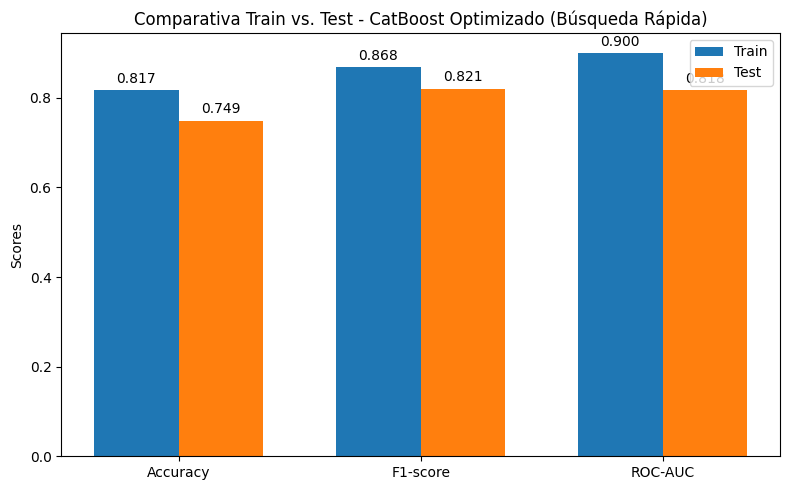

In [ ]:
# ==============================================================================
# 1. IMPORTACIONES (sin cambios)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from scipy.stats import randint, uniform

# ==============================================================================
# 2. FUNCIÓN DE GRÁFICO (sin cambios)
# ==============================================================================
def check_overfitting(model, X_train, y_train, X_test, y_test, model_name="Modelo"):
    # (El código de la función es el mismo que antes, lo omito por brevedad)
    print(f"\n=== Verificación de Overfitting: {model_name} ===")
    y_train_pred = model.predict(X_train)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]
    print(f"Train -> Accuracy: {accuracy_score(y_train, y_train_pred):.4f}, F1: {f1_score(y_train, y_train_pred):.4f}, AUC: {roc_auc_score(y_train, y_train_proba):.4f}")
    print(f"Test  -> Accuracy: {accuracy_score(y_test, y_test_pred):.4f}, F1: {f1_score(y_test, y_test_pred):.4f}, AUC: {roc_auc_score(y_test, y_test_proba):.4f}")
    labels = ["Accuracy", "F1-score", "ROC-AUC"]; train_scores = [accuracy_score(y_train, y_train_pred), f1_score(y_train, y_train_pred), roc_auc_score(y_train, y_train_proba)]; test_scores = [accuracy_score(y_test, y_test_pred), f1_score(y_test, y_test_pred), roc_auc_score(y_test, y_test_proba)]; x = np.arange(len(labels)); width = 0.35; fig, ax = plt.subplots(figsize=(8, 5)); rects1 = ax.bar(x - width/2, train_scores, width, label='Train'); rects2 = ax.bar(x + width/2, test_scores, width, label='Test'); ax.set_ylabel('Scores'); ax.set_title(f'Comparativa Train vs. Test - {model_name}'); ax.set_xticks(x, labels); ax.legend(); ax.bar_label(rects1, padding=3, fmt='%.3f'); ax.bar_label(rects2, padding=3, fmt='%.3f'); fig.tight_layout(); plt.show()


# ==============================================================================
# 3. CARGA DE DATOS (sin cambios)
# ==============================================================================
print("\n" + "="*50 + "\nCARGANDO Y PREPARANDO DATOS\n" + "="*50)
# (Tu código de carga y preparación de datos va aquí)
# Asumimos que X_train_cat, y_train_cat, X_test_cat, y_test_cat ya existen
# --- Cargar CSV (con datos de ejemplo por si falla) ---
try:
    df_train = pd.read_csv('/content/drive/My Drive/Datos_train_sAct.csv')
    df_test  = pd.read_csv('/content/drive/My Drive/Datos_test_sAct.csv')
except FileNotFoundError:
    print("⚠️ Archivos no encontrados. Usando datos de ejemplo para demostración.")
    from sklearn.datasets import make_classification
    X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_redundant=5, n_classes=2, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    df_train = pd.DataFrame(X_train, columns=[f'feature_{i}' for i in range(X_train.shape[1])]); df_train['Baja General'] = y_train
    df_test = pd.DataFrame(X_test, columns=[f'feature_{i}' for i in range(X_test.shape[1])]); df_test['Baja General'] = y_test
    df_train['Fecha de evaluación_num'] = 0; df_test['Fecha de evaluación_num'] = 0
    df_train['Inscripción / Reinscripción'] = 'dummy'; df_test['Inscripción / Reinscripción'] = 'dummy'
df_train = df_train.drop(['Fecha de evaluación_num', 'Inscripción / Reinscripción'], axis=1)
df_test = df_test.drop(['Fecha de evaluación_num', 'Inscripción / Reinscripción'], axis=1)
X_train_cat = df_train.drop(['Baja General'], axis=1); y_train_cat = df_train['Baja General'].astype(int)
X_test_cat  = df_test.drop(['Baja General'], axis=1); y_test_cat = df_test['Baja General'].astype(int)
categorical_features = X_train_cat.select_dtypes(include=['object', 'category']).columns.tolist()
if categorical_features:
    for col in categorical_features:
        X_train_cat[col] = X_train_cat[col].astype('category')
        X_test_cat[col] = X_test_cat[col].astype('category')


# ==============================================================================
# 4. BÚSQUEDA RÁPIDA CON RANDOMIZEDSEARCHCV
# ==============================================================================
print("\n" + "="*50 + "\nINICIANDO BÚSQUEDA RÁPIDA\n" + "="*50)

# 1. Modelo base
model = CatBoostClassifier(
    cat_features=categorical_features,
    verbose=0,
    random_state=42
)

# 2. Espacio de búsqueda (sin cambios, sigue siendo amplio)
param_dist = {
    'iterations': randint(500, 1500),
    'learning_rate': uniform(0.01, 0.1),
    'depth': randint(3, 8),
    'l2_leaf_reg': uniform(1, 10),
    'subsample': uniform(0.6, 0.4)
}

# 3. Configurar la búsqueda aleatoria - AQUÍ ESTÁN LOS CAMBIOS
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=15,          # 🔥 REDUCIDO: Probar solo 15 combinaciones en lugar de 50.
    cv=2,               # 🔥 REDUCIDO: Usar 2 folds en lugar de 3.
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 4. 🔥 IMPORTANTE: Preparamos los parámetros para el early stopping
# Esto detendrá el entrenamiento de modelos malos de forma temprana
fit_params = {
    'early_stopping_rounds': 50,
    # Usaremos el set de test como set de validación para el early stopping
    'eval_set': [(X_test_cat, y_test_cat)]
}

# 5. Ejecutar la búsqueda pasando los fit_params
random_search.fit(X_train_cat, y_train_cat, **fit_params)

print("\n--- Búsqueda Finalizada ---")
print("Mejor puntaje (AUC en CV):", random_search.best_score_)
print("Mejores hiperparámetros:", random_search.best_params_)

# ==============================================================================
# 6. ENTRENAR Y EVALUAR EL MODELO FINAL (sin cambios)
# ==============================================================================
print("\n" + "="*50 + "\nENTRENANDO MODELO FINAL\n" + "="*50)

best_model = random_search.best_estimator_

check_overfitting(
    best_model,
    X_train_cat, y_train_cat,
    X_test_cat, y_test_cat,
    model_name="CatBoost Optimizado (Búsqueda Rápida)"
)


CARGANDO Y PREPARANDO DATOS

INICIANDO BÚSQUEDA RÁPIDA
Fitting 2 folds for each of 15 candidates, totalling 30 fits

--- Búsqueda Finalizada ---
Mejor puntaje (AUC en CV): 0.8003801945313332
Mejores hiperparámetros: {'depth': 4, 'iterations': 691, 'l2_leaf_reg': np.float64(10.922115592912174), 'learning_rate': np.float64(0.07174815096277165), 'subsample': np.float64(0.8446612641953124)}

ENTRENANDO MODELO FINAL

=== Verificación de Overfitting: CatBoost Optimizado (Búsqueda Rápida) ===
Train -> Accuracy: 0.8168, F1: 0.8681, AUC: 0.8999
Test  -> Accuracy: 0.7489, F1: 0.8207, AUC: 0.8175


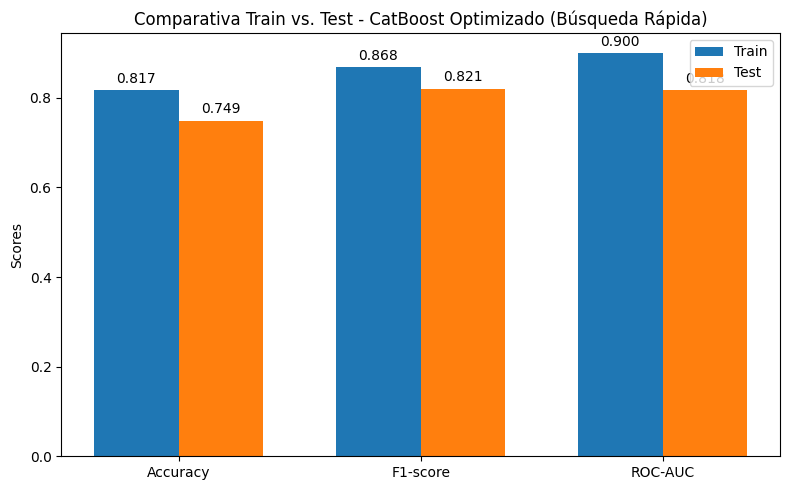

In [ ]:
# ======================================================================
# 1. IMPORTACIONES
# ======================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from scipy.stats import randint, uniform

# ======================================================================
# 2. FUNCIÓN PARA VERIFICAR OVERFITTING
# ======================================================================
def check_overfitting(model, X_train, y_train, X_test, y_test, model_name="Modelo"):
    print(f"\n=== Verificación de Overfitting: {model_name} ===")

    y_train_pred = model.predict(X_train)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    print(f"Train -> Accuracy: {accuracy_score(y_train, y_train_pred):.4f}, "
          f"F1: {f1_score(y_train, y_train_pred):.4f}, "
          f"AUC: {roc_auc_score(y_train, y_train_proba):.4f}")
    print(f"Test  -> Accuracy: {accuracy_score(y_test, y_test_pred):.4f}, "
          f"F1: {f1_score(y_test, y_test_pred):.4f}, "
          f"AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

    labels = ["Accuracy", "F1-score", "ROC-AUC"]
    train_scores = [accuracy_score(y_train, y_train_pred),
                    f1_score(y_train, y_train_pred),
                    roc_auc_score(y_train, y_train_proba)]
    test_scores = [accuracy_score(y_test, y_test_pred),
                   f1_score(y_test, y_test_pred),
                   roc_auc_score(y_test, y_test_proba)]

    x = np.arange(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    rects1 = ax.bar(x - width/2, train_scores, width, label='Train')
    rects2 = ax.bar(x + width/2, test_scores, width, label='Test')
    ax.set_ylabel('Scores')
    ax.set_title(f'Comparativa Train vs. Test - {model_name}')
    ax.set_xticks(x, labels)
    ax.legend()
    ax.bar_label(rects1, padding=3, fmt='%.3f')
    ax.bar_label(rects2, padding=3, fmt='%.3f')
    fig.tight_layout()
    plt.show()


# ======================================================================
# 3. CARGA DE DATOS
# ======================================================================
print("\n" + "="*50 + "\nCARGANDO Y PREPARANDO DATOS\n" + "="*50)

# --- Cargar CSV ---
df_train = pd.read_csv('/content/drive/My Drive/Datos_train_sAct.csv')
df_test  = pd.read_csv('/content/drive/My Drive/Datos_test_sAct.csv')

# --- Eliminar columnas innecesarias ---
df_train = df_train.drop(['Fecha de evaluación_num', 'Inscripción / Reinscripción'], axis=1)
df_test  = df_test.drop(['Fecha de evaluación_num', 'Inscripción / Reinscripción'], axis=1)

# --- Separar variables ---
X_train_cat = df_train.drop(['Baja General'], axis=1)
y_train_cat = df_train['Baja General'].astype(int)
X_test_cat  = df_test.drop(['Baja General'], axis=1)
y_test_cat  = df_test['Baja General'].astype(int)

# --- Identificar variables categóricas ---
categorical_features = X_train_cat.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_features:
    X_train_cat[col] = X_train_cat[col].astype('category')
    X_test_cat[col] = X_test_cat[col].astype('category')


# ======================================================================
# 4. BÚSQUEDA DE HIPERPARÁMETROS (RÁPIDA)
# ======================================================================
print("\n" + "="*50 + "\nINICIANDO BÚSQUEDA RÁPIDA\n" + "="*50)

# Modelo base
model = CatBoostClassifier(
    cat_features=categorical_features,
    verbose=0,
    random_state=42
)

# Espacio de búsqueda
param_dist = {
    'iterations': randint(500, 1500),
    'learning_rate': uniform(0.01, 0.1),
    'depth': randint(3, 8),
    'l2_leaf_reg': uniform(1, 10),
    'subsample': uniform(0.6, 0.4)
}

# Configurar búsqueda aleatoria
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=15,        # rápido
    cv=2,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Early stopping usando el test como validación
fit_params = {
    'early_stopping_rounds': 50,
    'eval_set': [(X_test_cat, y_test_cat)]
}

# Ejecutar búsqueda
random_search.fit(X_train_cat, y_train_cat, **fit_params)

print("\n--- Búsqueda Finalizada ---")
print("Mejor puntaje (AUC en CV):", random_search.best_score_)
print("Mejores hiperparámetros:", random_search.best_params_)


# ======================================================================
# 5. ENTRENAR Y EVALUAR EL MODELO FINAL
# ======================================================================
print("\n" + "="*50 + "\nENTRENANDO MODELO FINAL\n" + "="*50)

best_model = random_search.best_estimator_

check_overfitting(
    best_model,
    X_train_cat, y_train_cat,
    X_test_cat, y_test_cat,
    model_name="CatBoost Optimizado (Búsqueda Rápida)"
)

## RNN

In [ ]:
# ==============================================================================
# 1. IMPORTACIONES NECESARIAS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import optuna

# ==============================================================================
# 2. CARGA Y PREPARACIÓN DE DATOS
# ==============================================================================
print("\n" + "="*50 + "\nCARGANDO DATOS\n" + "="*50)

# --- Cargar los CSV directamente ---
df_redes_train = pd.read_csv('/content/drive/My Drive/Datos_train_sAct.csv')
df_redes_test  = pd.read_csv('/content/drive/My Drive/Datos_test_sAct.csv')
print("Archivos CSV cargados correctamente.")

# --- Eliminar columnas innecesarias ---
cols_to_drop = ['Fecha de evaluación_num', 'Inscripción / Reinscripción']
df_redes_train = df_redes_train.drop(columns=[c for c in cols_to_drop if c in df_redes_train.columns])
df_redes_test  = df_redes_test.drop(columns=[c for c in cols_to_drop if c in df_redes_test.columns])

# --- Separar variables ---
X_train = df_redes_train.drop('Baja General', axis=1)
y_train = df_redes_train['Baja General']
X_test  = df_redes_test.drop('Baja General', axis=1)
y_test  = df_redes_test['Baja General']

# --- Identificar columnas categóricas ---
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

# --- One-Hot Encoding ---
X_train = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

# --- Alinear columnas entre train y test ---
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# --- Escalar los datos ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Crear set de validación (solo del train) ---
val_ratio = 0.2
val_size = int(len(X_train_scaled) * val_ratio)

X_val_split = X_train_scaled[-val_size:]
y_val_split = y_train.iloc[-val_size:]
X_train_split = X_train_scaled[:-val_size]
y_train_split = y_train.iloc[:-val_size]

# ==============================================================================
# 3. BÚSQUEDA DE LA MEJOR ARQUITECTURA CON OPTUNA
# ==============================================================================
print("\n" + "="*50 + "\nBUSCANDO RED NEURONAL CON MENOS OVERFITTING\n" + "="*50)

def objective(trial):
    # --- 1. Hiperparámetros ---
    n_layers = trial.suggest_int('n_layers', 1, 3)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    l2_factor = trial.suggest_float('l2_factor', 1e-5, 1e-2, log=True)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    # --- 2. Modelo ---
    model = Sequential()
    model.add(Input(shape=(X_train_split.shape[1],)))

    for i in range(n_layers):
        n_units = trial.suggest_int(f'n_units_l{i}', 32, 256, log=True)
        model.add(Dense(n_units, activation='relu', kernel_regularizer=l2(l2_factor)))
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))

    # --- 3. Compilar ---
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['AUC'])

    # --- 4. Entrenar ---
    early_stopping = EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, mode='max')
    model.fit(X_train_split, y_train_split,
              validation_data=(X_val_split, y_val_split),
              epochs=200,
              batch_size=64,
              callbacks=[early_stopping],
              verbose=0)

    # --- 5. Calcular score ---
    train_auc = roc_auc_score(y_train_split, model.predict(X_train_split, verbose=0))
    val_auc = roc_auc_score(y_val_split, model.predict(X_val_split, verbose=0))
    overfitting_gap = abs(train_auc - val_auc)
    score = val_auc - overfitting_gap
    return score

# --- Ejecutar búsqueda ---
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print("\n--- Búsqueda Finalizada ---")
print("Mejor score de generalización:", study.best_value)
print("Mejores hiperparámetros:", study.best_params)

# ==============================================================================
# 4. ENTRENAR Y EVALUAR EL MODELO FINAL
# ==============================================================================
print("\n" + "="*50 + "\nENTRENANDO MODELO FINAL CON MEJOR ARQUITECTURA\n" + "="*50)

best_params = study.best_params
final_model = Sequential()
final_model.add(Input(shape=(X_train_scaled.shape[1],)))

for i in range(best_params['n_layers']):
    final_model.add(Dense(best_params[f'n_units_l{i}'], activation='relu',
                          kernel_regularizer=l2(best_params['l2_factor'])))
    final_model.add(Dropout(best_params['dropout_rate']))

final_model.add(Dense(1, activation='sigmoid'))

final_model.compile(optimizer=Adam(learning_rate=best_params['learning_rate']),
                    loss='binary_crossentropy',
                    metrics=['AUC'])

early_stopping_final = EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, mode='max')

final_model.fit(X_train_split, y_train_split,
                validation_data=(X_val_split, y_val_split),
                epochs=100,
                batch_size=64,
                callbacks=[early_stopping_final],
                verbose=1)

# --- Evaluación Final ---
train_auc_final = roc_auc_score(y_train, final_model.predict(X_train_scaled, verbose=0))
test_auc_final = roc_auc_score(y_test, final_model.predict(X_test_scaled, verbose=0))

print("\n--- Resultados Finales ---")
print(f"AUC en Train: {train_auc_final:.4f}")
print(f"AUC en Test:  {test_auc_final:.4f}")
print(f"Gap de Overfitting: {abs(train_auc_final - test_auc_final):.4f}")


CARGANDO DATOS
Archivos CSV cargados correctamente.


[I 2025-10-08 17:47:37,947] A new study created in memory with name: no-name-05a43975-d6cb-483d-8da3-b267df6444f4



BUSCANDO RED NEURONAL CON MENOS OVERFITTING


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,loss,val_AUC,val_loss
  current = self.get_monitor_value(logs)
[I 2025-10-08 17:48:16,004] Trial 0 finished with value: 0.28852536747273594 and parameters: {'n_layers': 2, 'dropout_rate': 0.10529394618113415, 'l2_factor': 0.0005699725293830677, 'learning_rate': 0.00013976113308726697, 'n_units_l0': 65, 'n_units_l1': 121}. Best is trial 0 with value: 0.28852536747273594.
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,loss,val_AUC,val_loss
  current = self.get_monitor_value(logs)
[I 2025-10-08 17:48:47,696] Trial 1 finished with value: 0.2995495495495495 and parameters: {'n_layers': 3, 'dropout_rate': 0.4086534234563415, 'l2_factor': 1.0616569782064666e


--- Búsqueda Finalizada ---
Mejor score de generalización: 0.38691322901849223
Mejores hiperparámetros: {'n_layers': 2, 'dropout_rate': 0.1870831277409451, 'l2_factor': 0.0016363023575645913, 'learning_rate': 0.0030209568887471575, 'n_units_l0': 137, 'n_units_l1': 134}

ENTRENANDO MODELO FINAL CON MEJOR ARQUITECTURA
Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - AUC: 0.5542 - loss: 1.2167 - val_AUC: 0.6495 - val_loss: 1.1752
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 0.8969 - loss: 0.8177 - val_AUC: 0.6967 - val_loss: 1.0719
Epoch 3/100
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - AUC: 0.9646 - loss: 0.6513

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,loss,val_AUC,val_loss
  current = self.get_monitor_value(logs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - AUC: 0.9615 - loss: 0.6460 - val_AUC: 0.6779 - val_loss: 1.2492
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 0.9876 - loss: 0.5169 - val_AUC: 0.6764 - val_loss: 1.2799
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 0.9924 - loss: 0.4518 - val_AUC: 0.6578 - val_loss: 1.4433
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 0.9982 - loss: 0.3906 - val_AUC: 0.6401 - val_loss: 1.6291
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 0.9991 - loss: 0.3385 - val_AUC: 0.6578 - val_loss: 1.6841
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 0.9999 - loss: 0.2955 - val_AUC: 0.6513 - val_loss: 1.8660
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 1.0000 - loss: 0.2691 - val_AUC: 0.6521 - val_loss: 1.8522
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - AUC: 0.9997 - loss: 0.2543 - val_AUC: 0.6409 - val_loss: 2.0023
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - AUC: 0.9999 